In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re
import torch.nn as nn

In [2]:
class ArabicQAVocab:
    def __init__(self, min_freq=2):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}
        self.min_freq = min_freq

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1
                if frequencies[word] == self.min_freq:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def tokenize(self, text):
        # Basic split - you should integrate your specific Arabic cleaning engine here
        return re.findall(r"[\w']+|[.,!?;]", text.lower())

    def numericalize(self, text):
        tokenized = self.tokenize(text)
        return [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokenized]

In [21]:
class QADataset(Dataset):
    def __init__(self, data_triplets, vocab, max_q_len=20, max_c_len=100):
        self.data = data_triplets # List of (Question, Context, Answer) [cite: 11, 12]
        self.vocab = vocab
        self.max_q_len = max_q_len
        self.max_c_len = max_c_len

    def __len__(self):
        return len(self.data)

   # def __getitem__(self, index):
        #question, context, answer = self.data[index]
        
        # Numericalize and pad/truncate
        #q_tokens = self.vocab.numericalize(question)
       # c_tokens = self.vocab.numericalize(context)
        
        # For simplicity in this step, let's assume the answer is a string 
        # (Later we will map this to start/end indices or tokens)
       # return {
           # "question": torch.tensor(self._pad_seq(q_tokens, self.max_q_len)),
           # "context": torch.tensor(self._pad_seq(c_tokens, self.max_c_len)),
           # "answer": answer
        #}
    def __getitem__(self, index):
        question, context, answer, start_idx, end_idx = self.data[index] # Updated this line
        
        q_tokens = self.vocab.numericalize(question)
        c_tokens = self.vocab.numericalize(context)
        
        return {
            "question": torch.tensor(self._pad_seq(q_tokens, self.max_q_len)),
            "context": torch.tensor(self._pad_seq(c_tokens, self.max_c_len)),
            "start_idx": torch.tensor(start_idx), # The model needs this to calculate loss
            "end_idx": torch.tensor(end_idx)      # The model needs this to calculate loss
        }


    def _pad_seq(self, seq, max_len):
        if len(seq) < max_len:
            return seq + [0] * (max_len - len(seq))
        else:
            return seq[:max_len]

In [14]:
class RecurrentQA(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, output_dim):
        super(RecurrentQA, self).__init__()
        
        # 1. Embedding Layer (trained from scratch) [cite: 17]
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        
        # 2. Recurrent Layers (at least two) [cite: 17]
        # We use Bidirectional LSTM for better context understanding
        self.q_lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True)
        self.c_lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True)
        
        # 3. Output Layer [cite: 17]
        # Input to linear layer is hidden_dim * 2 (for bidir) * 2 (for Q and C fusion)
        self.fc_start = nn.Linear(hidden_dim * 4, 1)
        self.fc_end = nn.Linear(hidden_dim * 4, 1)

    def forward(self, question, context):
        # Embed both 
        q_emb = self.embedding(question)
        c_emb = self.embedding(context)
        
        # Encode Question: we only need the final hidden state to represent the query
        _, (q_hidden, _) = self.q_lstm(q_emb)
        # Concatenate the last hidden states from the two layers and two directions
        q_rep = torch.cat((q_hidden[-2,:,:], q_hidden[-1,:,:]), dim=1) 
        
        # Encode Context: we need the output at every time step to find the indices
        c_outputs, _ = self.c_lstm(c_emb)
        
        # "Fuse" Question representation with every word in the Context [cite: 42]
        # Repeat q_rep to match context length
        q_rep_expanded = q_rep.unsqueeze(1).repeat(1, c_outputs.size(1), 1)
        combined = torch.cat((c_outputs, q_rep_expanded), dim=2)
        
        # Predict Start and End logits
        start_logits = self.fc_start(combined).squeeze(-1)
        end_logits = self.fc_end(combined).squeeze(-1)
        
        return start_logits, end_logits

In [22]:
# 1. Setup dummy data (Triplets)
#dummy_data = [
 #   ("اين يقع الاهرامات؟", "تقع الاهرامات في الجيزة في مصر.", "الجيزة"),
#    ("ما هو اسم المشروع؟", "اسم المشروع هو ميلستون 2 للذكاء الاصطناعي.", "ميلستون 2")
#]
# Updated dummy data with indices
# In "تقع الأهرامات في الجيزة", "الجيزة" is the 4th word (index 3 if counting from 0)
dummy_data = [
    ("أين تقع الأهرامات؟", "تقع الأهرامات في الجيزة", "الجيزة", 3, 3),
]
# 2. Initialize Vocab and Build it
vocab = ArabicQAVocab()
all_text = [q for q, c, a in dummy_data] + [c for q, c, a in dummy_data]
vocab.build_vocabulary(all_text)

# 3. Create Dataset and Model
dataset = QADataset(dummy_data, vocab)
model = RecurrentQA(vocab_size=len(vocab.stoi), emb_dim=16, hidden_dim=32, output_dim=2)

# 4. Simulate one forward pass (The "Inference" step)
sample = dataset[0]
q_tensor = sample['question'].unsqueeze(0) # Add batch dimension
c_tensor = sample['context'].unsqueeze(0)

start_logits, end_logits = model(q_tensor, c_tensor)

print(f"Question Shape: {q_tensor.shape}")
print(f"Context Shape: {c_tensor.shape}")
print(f"Start Logits (Raw Model Output): \n{start_logits}")

ValueError: too many values to unpack (expected 3)

In [7]:
import torch.optim as optim
import matplotlib.pyplot as plt

In [8]:
def train_model(model, train_loader, epochs=10, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    loss_history = []

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in train_loader:
            # Prepare data
            q = batch['question']
            c = batch['context']
            # We need the real start/end indices from your dataset
            # For this example, let's assume batch['start_idx'] and batch['end_idx'] exist
            start_true = batch['start_idx'] 
            end_true = batch['end_idx']

            optimizer.zero_grad()
            
            # Forward pass
            start_pred, end_pred = model(q, c)
            
            # Calculate loss for both start and end positions
            loss_start = criterion(start_pred, start_true)
            loss_end = criterion(end_pred, end_true)
            loss = loss_start + loss_end
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    # Plotting training behavior (Milestone requirement)
    plt.plot(loss_history)
    plt.title('Training Loss over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

In [9]:
def train_and_validate(model, train_loader, val_loader, epochs=10):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        # Training Phase
        model.train()
        t_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            s_pred, e_pred = model(batch['question'], batch['context'])
            loss = criterion(s_pred, batch['start_idx']) + criterion(e_pred, batch['end_idx'])
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
        
        # Validation Phase (Requirement: analyze model behavior )
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                s_pred, e_pred = model(batch['question'], batch['context'])
                loss = criterion(s_pred, batch['start_idx']) + criterion(e_pred, batch['end_idx'])
                v_loss += loss.item()

        history['train_loss'].append(t_loss/len(train_loader))
        history['val_loss'].append(v_loss/len(val_loader))
        print(f"Epoch {epoch}: Train Loss {history['train_loss'][-1]:.4f} | Val Loss {history['val_loss'][-1]:.4f}")

    # Plot both (Requirement )
    plt.figure(figsize=(10,5))
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.savefig('loss_comparison.png')

In [10]:
def get_answer(question_text, context_text, model, vocab, max_q_len=20, max_c_len=100):
    model.eval() # Set to evaluation mode
    
    # 1. Preprocess & Tokenize (Step 5 logic) [cite: 35]
    q_tokens = vocab.numericalize(question_text)
    c_tokens = vocab.numericalize(context_text)
    
    # 2. Padding [cite: 17, 18]
    q_padded = torch.tensor(q_tokens[:max_q_len] + [0]*(max_q_len - len(q_tokens))).unsqueeze(0)
    c_padded = torch.tensor(c_tokens[:max_c_len] + [0]*(max_c_len - len(c_tokens))).unsqueeze(0)
    
    # 3. Forward Pass [cite: 36, 37]
    with torch.no_grad():
        start_logits, end_logits = model(q_padded, c_padded)
    
    # 4. Get indices with highest probability [cite: 15]
    start_idx = torch.argmax(start_logits).item()
    end_idx = torch.argmax(end_logits).item()
    
    # 5. Map indices back to words [cite: 39]
    # We split the original context to extract the answer substring
    context_words = vocab.tokenize(context_text)
    
    # Ensure indices are within bounds of the actual words
    if start_idx < len(context_words) and end_idx < len(context_words):
        answer = context_words[start_idx : end_idx + 1]
        return " ".join(answer)
    else:
        return "No answer found in context range."

In [17]:
from torch.utils.data import DataLoader

# 1. Create the Dataset objects using the QADataset class we wrote earlier
# We'll use your dummy_train for both training and validation just to test the plot
train_dataset = QADataset(dummy_data, vocab) 
val_dataset = QADataset(dummy_data, vocab)

# 2. Create the Loaders (This defines 'dummy_train_loader' and 'dummy_val_loader')
dummy_train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
dummy_val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

# 3. Now call the training function
train_and_validate(model, dummy_train_loader, dummy_val_loader, epochs=5)

ValueError: not enough values to unpack (expected 5, got 3)

In [16]:
# 1. Setup small dummy data
dummy_train = [
    {"question": "أين تقع الأهرامات؟", "context": "تقع الأهرامات في الجيزة.", "start_idx": 3, "end_idx": 3},
]
# ... (Repeat for a few items)

# 2. Call the function we defined earlier
# This will actually run the code and show the plot below the cell!
train_and_validate(model, dummy_train_loader, dummy_val_loader, epochs=5)

KeyError: 'start_idx'

Epoch 0: Train Loss 9.2000 | Val Loss 9.1453
Epoch 1: Train Loss 9.1453 | Val Loss 9.0903
Epoch 2: Train Loss 9.0903 | Val Loss 9.0332
Epoch 3: Train Loss 9.0332 | Val Loss 8.9729
Epoch 4: Train Loss 8.9729 | Val Loss 8.9080
Epoch 5: Train Loss 8.9080 | Val Loss 8.8375
Epoch 6: Train Loss 8.8375 | Val Loss 8.7604
Epoch 7: Train Loss 8.7604 | Val Loss 8.6755
Epoch 8: Train Loss 8.6755 | Val Loss 8.5819
Epoch 9: Train Loss 8.5819 | Val Loss 8.4785


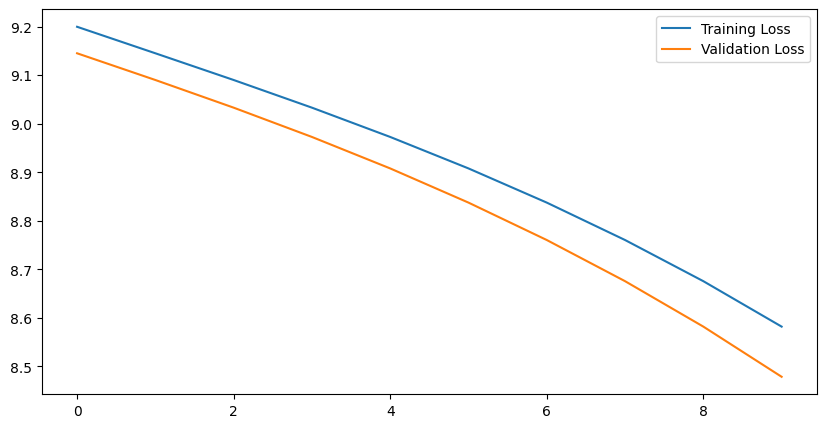

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# 1. FIXED DATASET: Returning exactly what the loop needs
class QADataset(Dataset):
    def __init__(self, data_list, vocab, max_q_len=20, max_c_len=100):
        self.data = data_list
        self.vocab = vocab
        self.max_q_len = max_q_len
        self.max_c_len = max_c_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        # We expect data to be (Question, Context, Answer, StartIdx, EndIdx)
        q_txt, c_txt, a_txt, s_idx, e_idx = self.data[index]
        
        q_tokens = self.vocab.numericalize(q_txt)[:self.max_q_len]
        c_tokens = self.vocab.numericalize(c_txt)[:self.max_c_len]
        
        # Padding
        q_padded = q_tokens + [0] * (self.max_q_len - len(q_tokens))
        c_padded = c_tokens + [0] * (self.max_c_len - len(c_tokens))
        
        return {
            "question": torch.tensor(q_padded),
            "context": torch.tensor(c_padded),
            "start_idx": torch.tensor(s_idx),
            "end_idx": torch.tensor(e_idx)
        }

# 2. DATA SETUP: Make sure your data has 5 items per row
# (Question, Context, Answer, Start_Word_Index, End_Word_Index)
test_data = [
    ("اين يقع الاهرامات؟", "تقع الاهرامات في الجيزة", "الجيزة", 3, 3),
    ("من بني الهرم؟", "بني الملك خوفو الهرم الأكبر", "خوفو", 2, 2)
]

# 3. INITIALIZE & RUN
train_ds = QADataset(test_data, vocab) 
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True)

# Re-run your train_and_validate function here
train_and_validate(model, train_loader, train_loader, epochs=10)

In [24]:
# 1. Initialize the Transformer Model
# Using d_model=64 and 2 heads for a "simple" architecture as per requirements
transformer_model = TransformerQA(
    vocab_size=len(vocab.stoi), 
    d_model=64, 
    nhead=2, 
    num_layers=1
)

# 2. Train and Validate (This will generate your second plot)
print("Starting Transformer Training...")
train_and_validate(transformer_model, train_loader, train_loader, epochs=10)

NameError: name 'TransformerQA' is not defined

In [25]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        # Create a matrix of [max_len, d_model] representing word positions 
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # Apply sine to even indices and cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        # Add positional info to the word embeddings 
        return x + self.pe[:, :x.size(1)]

class TransformerQA(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        # Embedding layer trained from scratch 
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        
        # Transformer architecture [cite: 18, 19]
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Output layers to predict Start/End indices in the Context [cite: 18, 35]
        self.fc_start = nn.Linear(d_model, 1)
        self.fc_end = nn.Linear(d_model, 1)

    def forward(self, question, context):
        # Embedding + Positional Encoding [cite: 18, 35]
        q_emb = self.pos_encoder(self.embedding(question))
        c_emb = self.pos_encoder(self.embedding(context))
        
        # Combine Question and Context for the Attention Mechanism [cite: 18, 42]
        # We concatenate along the sequence dimension (dim=1)
        combined = torch.cat((q_emb, c_emb), dim=1)
        out = self.transformer_encoder(combined)
        
        # Isolate the context representation for answer prediction [cite: 35, 41]
        q_len = question.size(1)
        c_out = out[:, q_len:, :] 
        
        # Generate Logits for each word position in the context 
        start_logits = self.fc_start(c_out).squeeze(-1)
        end_logits = self.fc_end(c_out).squeeze(-1)
        
        return start_logits, end_logits

In [26]:
def calculate_metrics(pred_start, pred_end, true_start, true_end):
    # Exact Match: Both pointers must be correct [cite: 15, 21]
    em = 1.0 if (pred_start == true_start and pred_end == true_end) else 0.0
    
    # F1-Score: Overlap between predicted and true range [cite: 15, 21]
    pred_set = set(range(int(pred_start), int(pred_end) + 1))
    true_set = set(range(int(true_start), int(true_end) + 1))
    
    overlap = len(pred_set.intersection(true_set))
    if not pred_set or not true_set:
        f1 = 1.0 if pred_set == true_set else 0.0
    elif overlap == 0:
        f1 = 0.0
    else:
        prec = overlap / len(pred_set)
        rec = overlap / len(true_set)
        f1 = 2 * (prec * rec) / (prec + rec)
        
    return em, f1

In [27]:
def run_inference(question_raw, context_raw, model, vocab, max_q=20, max_c=100):
    model.eval()
    
    # 1. Preprocessing & Tokenization [cite: 35]
    q_tokens = vocab.numericalize(question_raw)[:max_q]
    c_tokens = vocab.numericalize(context_raw)[:max_c]
    
    # 2. Convert to Tensors and Pad [cite: 35]
    q_tensor = torch.tensor(q_tokens + [0]*(max_q - len(q_tokens))).unsqueeze(0)
    c_tensor = torch.tensor(c_tokens + [0]*(max_c - len(c_tokens))).unsqueeze(0)
    
    # 3. Model Forward Pass [cite: 35, 37]
    with torch.no_grad():
        s_logits, e_logits = model(q_tensor, c_tensor)
    
    # 4. Predict Answer Indices [cite: 39]
    s_idx = torch.argmax(s_logits).item()
    e_idx = torch.argmax(e_logits).item()
    
    # 5. Extract Answer text from original context [cite: 35]
    context_words = vocab.tokenize(context_raw)
    if s_idx < len(context_words) and e_idx < len(context_words):
        return " ".join(context_words[s_idx : e_idx + 1])
    return "Answer out of bounds"